In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [2]:
!make clean
!make

rm -f test_deque_pop_back test_deque_pop_back_multi test_deque_pop_front test_deque_pop_front_multi test_deque_pop_push_rand test_deque_push_back test_deque_push_back_multi test_deque_push_front test_deque_push_front_multi test_hold_pop_back test_hold_pop_back_multi test_hold_pop_front test_hold_pop_front_multi test_hold_pop_push_rand test_hold_push_back test_hold_push_back_multi test_hold_push_front test_hold_push_front_multi test_hold_wait_pop_back_multi test_hold_wait_pop_front_multi test_hold_wait_push_back_multi test_hold_wait_push_front_multi test_relax_pop_back test_relax_pop_back_multi test_relax_pop_front test_relax_pop_front_multi test_relax_pop_push_rand test_relax_push_back test_relax_push_back_multi test_relax_push_front test_relax_push_front_multi 
g++  -std=c++20 -pthread -Wall -I../../../../  test_deque_pop_back.cpp -o test_deque_pop_back
In file included from test_deque_pop_back.cpp:17:
In file included from ../../../../fdaPDE/multithreading.h:50:
../../../../fdaPDE/sr

In [93]:
def run_test(test_name,n_runs = 200,n_elems = 16000,n_threads = 1):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_threads, Iterable):
        n_threads = [n_threads]

    results = []
    for threads in n_threads:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $threads
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

In [94]:
def multi_plot(data1, data2, title, labels):

    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    ticks = []

    for i in range(0,len(data1)):
        boxes.append(data1[i])
        boxes.append(data2[i])
        ticks.append(str(n_threads[i]))
        ticks.append(str(n_threads[i]))
        colors.append("peachpuff")
        colors.append("orange")

    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)
    # Etichette per gli assi
    ax.set_xticks(range(1,1+len(boxes)),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.legend([bplot["boxes"][0], bplot["boxes"][1]], [labels[0], labels[1]], loc='upper left')

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()

In [95]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()


# Set number of runs

In [96]:
n_runs = 200

# Set number of threads

In [114]:
n_threads = [1,2,4,6,8]

# Set number of elements

In [98]:
n_elems = 16000

# Set test name

In [117]:
test_name = "pop_back"

# Run single-threaded test between all types of queues

In [100]:
test1 = run_test("test_deque_"+test_name,n_runs,n_elems,1)
test2 = run_test("test_hold_"+test_name,n_runs,n_elems,1)
test3 = run_test("test_hold_wait_"+test_name+"_multi",n_runs,n_elems,1)
test4 = run_test("test_relax_"+test_name,n_runs,n_elems,1)

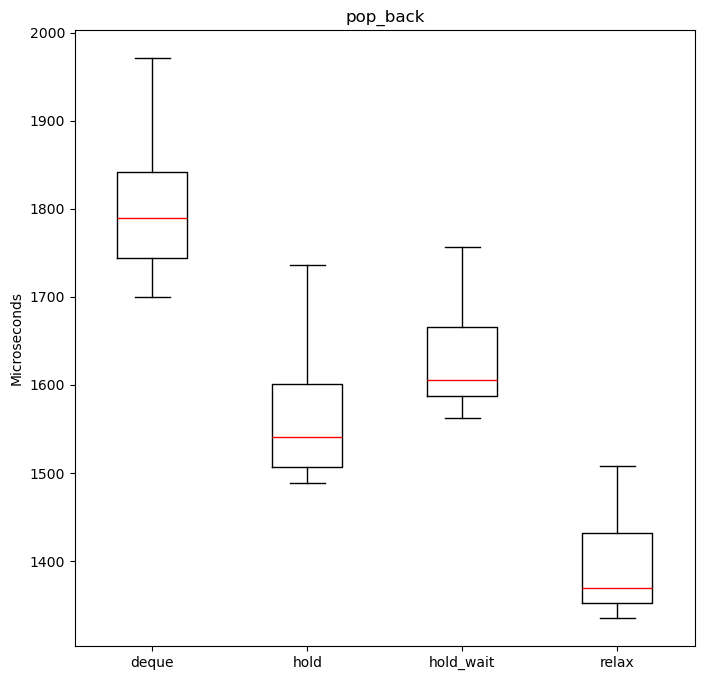

In [101]:
plot([test1[0],test2[0],test3[0],test4[0]],test_name,["deque","hold","hold_wait","relax"])

# Run multi-threaded test between two types of queues

In [118]:
#test1 = run_test("test_deque_"+test_name+"_multi",n_runs,n_elems,n_threads)
test2 = run_test("test_hold_"+test_name+"_multi",n_runs,n_elems,n_threads)
test3 = run_test("test_hold_wait_"+test_name+"_multi",n_runs,n_elems,n_threads)
#test4 = run_test("test_relax_"+test_name+"_multi",n_runs,n_elems,n_threads)

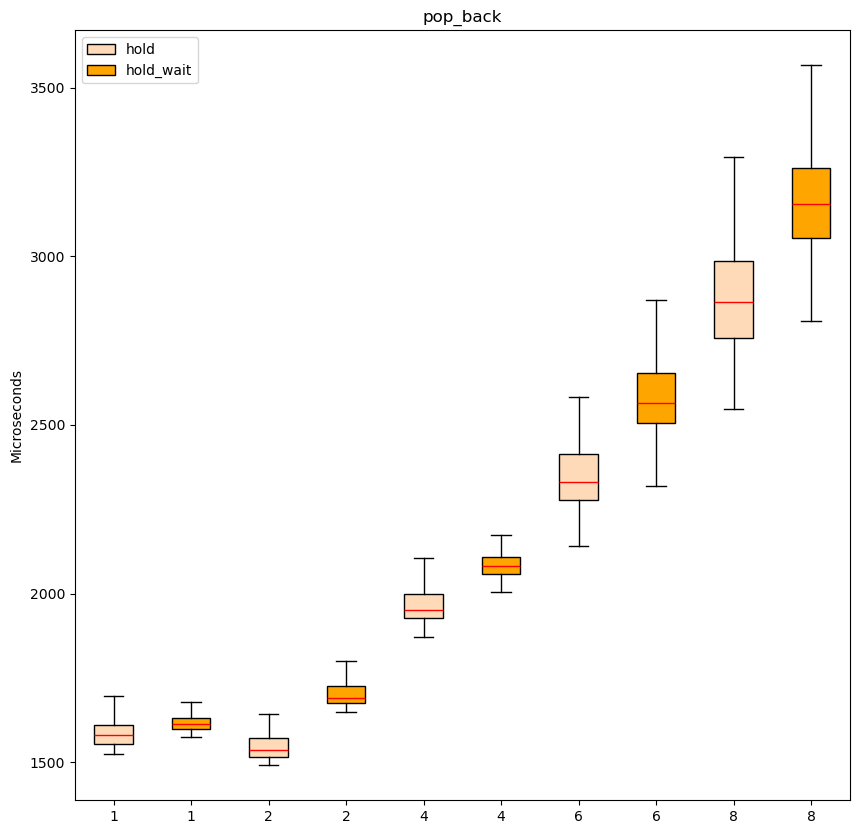

In [119]:
multi_plot(test2,test3,test_name,["hold","hold_wait"])